In [7]:
import torch
assert torch.cuda.is_available(), "GPU bağlı değil. egitime başlama"

device = torch.device("cuda")

print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print(
    "GPU VRAM:",
    round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1),
    "GB",
)

PyTorch: 2.11.0+cu128
CUDA: 12.8
GPU: NVIDIA A100-SXM4-40GB
GPU VRAM: 39.5 GB


In [8]:
!nvidia-smi

Tue Aug 18 20:55:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             50W /  400W |     898MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [9]:
import os 
import sys
import subprocess
from pathlib import Path

PROJECT_ROOT = Path("/content/fire_guncel_repo")
CODE_ARCHIVE = Path("/content/eytnet_code.tar")

assert CODE_ARCHIVE.is_file(), (
    f"Kod arşivi bulunamadı: {CODE_ARCHIVE}\n"
    "VS Code'da eytnet_code.tar dosyasına sağ tıklayıp "
    "'Upload to Colab' seç."
)

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

subprocess.run(
    [
        "tar",
        "-xf",
        str(CODE_ARCHIVE),
        "-C",
        str(PROJECT_ROOT)
    ],
    check=True
)

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Proje kökü:", PROJECT_ROOT)
print("Klasörler:", sorted(p.name for p in PROJECT_ROOT.iterdir()))

Proje kökü: /content/fire_guncel_repo
Klasörler: ['README.md', 'configs', 'eytnet', 'helpers', 'notebooks', 'pyproject.toml']


In [10]:
%pip install -q -U kagglehub

In [13]:
from pathlib import Path
import kagglehub

expected_counts = {
    "train": 3900,
    "val": 1300,
    "test": 1300,
}

downloaded_path = Path(
    kagglehub.dataset_download(
        "pengbo00/home-fire-dataset"
    )
)

candidates = [downloaded_path]

for images_dir in downloaded_path.rglob("images"):
    if images_dir.parent.name == "train":
        candidates.append(
            images_dir.parent.parent
        )

DATA_ROOT = next(
    candidate
    for candidate in candidates
    if all(
        (candidate / split / "images").is_dir()
        and (candidate / split / "labels").is_dir()
        for split in expected_counts
    )
)

print("Kullanılacak dataset:", DATA_ROOT)

for split, expected in expected_counts.items():
    image_count = len(
        list(
            (DATA_ROOT / split / "images")
            .glob("*.jpg")
        )
    )

    label_count = len(
        list(
            (DATA_ROOT / split / "labels")
            .glob("*.txt")
        )
    )

    print(
        f"{split:5s} | "
        f"images={image_count} | "
        f"labels={label_count}"
    )

    assert image_count == expected
    assert label_count == expected

print("Kaggle dataset eksiksiz.")

Using Colab cache for faster access to the 'home-fire-dataset' dataset.
Kullanılacak dataset: /kaggle/input/home-fire-dataset
train | images=3900 | labels=3900
val   | images=1300 | labels=1300
test  | images=1300 | labels=1300
Kaggle dataset eksiksiz.


In [14]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from eytnet.config import Config
from eytnet.dataset import build_dataloader
from eytnet.model import build_model
from eytnet.loss import EYTNetLoss
from eytnet.train import train

print("Tüm importlar başarılı.")

Tüm importlar başarılı.


In [15]:
import json

config_path = PROJECT_ROOT / "configs" / "experiment.json"
config_raw = json.loads(
    config_path.read_text(encoding="utf-8")
)
config_raw["data_root"] = str(DATA_ROOT)

cfg_test = Config(config_raw)

train_loader_test = build_dataloader(
    cfg_test,
    "train",
)
images, targets, metas = next(
    iter(train_loader_test)
)

print("Images:", images.shape, images.dtype)
print("Targets:", targets.shape)
print("Metas:", len(metas))
print(
    "Min/max:",
    images.min().item(),
    images.max().item(),
)

assert images.shape == (
    cfg_test.batch_size,
    3,
    640,
    640,
)
assert len(metas) == cfg_test.batch_size
assert images.min().item() >= 0.0
assert images.max().item() <= 1.0

del train_loader_test, images, targets, metas

print("Dataloader testi başarılı.")

Images: torch.Size([32, 3, 640, 640]) torch.float32
Targets: torch.Size([42, 6])
Metas: 32
Min/max: 0.0 1.0
Dataloader testi başarılı.


In [16]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
from pathlib import Path
DRIVE_RUNS = Path(
    "/content/drive/MyDrive/EYTNet/runs"
)
DRIVE_RUNS.mkdir(
    parents=True,
    exist_ok=True,
)

def load_colab_config(config_stem):
    config_path = (
        PROJECT_ROOT
        / "configs"
        / f"{config_stem}.json"
    )

    raw = json.loads(
        config_path.read_text(encoding="utf-8")
    )

    raw["data_root"] = str(DATA_ROOT)
    cfg = Config(raw)

    # Drive'a kaydedilecek config taşınabilir kalsın.
    cfg.raw["data_root"] = "data"
    cfg.data_root = DATA_ROOT
    cfg.run_dir = (
        DRIVE_RUNS / cfg.experiment_name
    )

    return cfg

print("Kalıcı sonuç klasörü:", DRIVE_RUNS)

Kalıcı sonuç klasörü: /content/drive/MyDrive/EYTNet/runs


In [51]:
CONFIGS = [
    "experiment_adam_lr5e4",
    "experiment",
    "experiment_adam_lr2e3",
    "experiment_sgd",
    "experiment_adam_wd1e4",
    "experiment_no_augmentation",
]

completed_runs = []

for config_name in CONFIGS:
    cfg = load_colab_config(config_name)

    last_checkpoint = (
        cfg.run_dir / "weights" / "last.pt"
    )

    resume = last_checkpoint.exists()

    print("\n" + "=" * 70)
    print("Config:", config_name)
    print("Deney:", cfg.experiment_name)
    print("Optimizer:", cfg.optimizer)
    print("Learning rate:", cfg.learning_rate)
    print("Wright decay:", cfg.weight_decay)
    print("Augmentatin:", cfg.augmentation_enabled)
    print("checopint'ten devam:", resume)

    model, run_dir, history = train(
        cfg,
        device=device,
        resume=resume,
    )

    completed_runs.append(
        {
            "config": config_name,
            "run_name": cfg.experiment_name,
            "run_dir": run_dir,
        }
    )

print("\nBütün kısa deneyler tamamlandı.")



Config: experiment_adam_lr5e4
Deney: hparam_adam_lr5e4
Optimizer: adam
Learning rate: 0.0005
Wright decay: 0.0005
Augmentatin: True
checopint'ten devam: True
Devam: epoch 12 sonrasindan, en iyi mAP 0.0839
hparam_adam_lr5e4 | 7,208,138 parametre | cuda
En iyi validation mAP@0.5: 0.0839
Agirliklar: /content/drive/MyDrive/EYTNet/runs/hparam_adam_lr5e4/weights/best.pt

Config: experiment
Deney: hparam_adam_lr1e3
Optimizer: adam
Learning rate: 0.001
Wright decay: 0.0005
Augmentatin: True
checopint'ten devam: True
Devam: epoch 12 sonrasindan, en iyi mAP 0.1419
hparam_adam_lr1e3 | 7,208,138 parametre | cuda
En iyi validation mAP@0.5: 0.1419
Agirliklar: /content/drive/MyDrive/EYTNet/runs/hparam_adam_lr1e3/weights/best.pt

Config: experiment_adam_lr2e3
Deney: hparam_adam_lr2e3
Optimizer: adam
Learning rate: 0.002
Wright decay: 0.0005
Augmentatin: True
checopint'ten devam: True
Devam: epoch 7 sonrasindan, en iyi mAP 0.0010
hparam_adam_lr2e3 | 7,208,138 parametre | cuda
  [50/121] loss=4.8986 lr

In [ ]:
scheduler_runs = [
    {
        "name": "Cosine + warmup",
        "run_dir": (
            DRIVE_RUNS
            / "hparam_adam_wd1e4"
        ),
    },
    {
        "name": "Static LR",
        "run_dir": (
            DRIVE_RUNS
            / "hparam_adam_wd1e4_static"
        ),
    },
]

scheduler_rows = []

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

for run in scheduler_runs:
    metrics_path = (
        run["run_dir"] / "metrics.csv"
    )

    assert metrics_path.is_file(), (
        f"Sonuç bulunamadı: {metrics_path}"
    )

    df = pd.read_csv(metrics_path)

    df = (
        df.drop_duplicates(
            subset="epoch",
            keep="last",
        )
        .sort_values("epoch")
    )

    # İki deney de yalnızca ilk 12 epoch ile karşılaştırılır.
    df = df[df["epoch"] <= 12]

    best = df.loc[df["map50"].idxmax()]

    scheduler_rows.append(
        {
            "scheduler": run["name"],
            "best_epoch": int(best["epoch"]),
            "mAP@0.5": float(best["map50"]),
            "precision": float(best["precision"]),
            "recall": float(best["recall"]),
            "F1": float(best["f1"]),
            "F2": float(best["f2"]),
        }
    )

    axes[0].plot(
        df["epoch"],
        df["map50"],
        marker="o",
        label=run["name"],
    )

    axes[1].plot(
        df["epoch"],
        df["train_loss"],
        marker="o",
        label=run["name"],
    )

scheduler_comparison = (
    pd.DataFrame(scheduler_rows)
    .sort_values(
        ["mAP@0.5", "F2"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(scheduler_comparison.round(4))

axes[0].set_title("Validation mAP@0.5")
axes[1].set_title("Training loss")

for axis in axes:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.3)
    axis.legend()

plt.suptitle(
    "Cosine scheduler ve static LR karşılaştırması"
)
plt.tight_layout()
plt.show()

print(
    "Seçilen scheduler:",
    scheduler_comparison.iloc[0]["scheduler"],
)

In [52]:
rows = []

for run in completed_runs:
    metrics_path = (
        run["run_dir"] / "metrics.csv"
    )

    df = pd.read_csv(metrics_path)

    df = (
        df.drop_duplicates(subset="epoch", keep = "last",)
    .sort_values("epoch")
    )

    best = df.loc[df["map50"].idxmax()]

    rows.append(
        {
            "deney": run["run_name"],
            "best_epoch": int(best["epoch"]),
            "mAP@0.5": float(best["map50"]),
            "precision": float(best["precision"]),
            "recall": float(best["recall"]),
            "F1": float(best["f1"]),
            "F2": float(best["f2"]),
        }
    )

comparison = (
    pd.DataFrame(rows)
    .sort_values("mAP@0.5", ascending=False)
    .reset_index(drop=True)
)

display(comparison.round(4))


,deney,best_epoch,mAP@0.5,precision,recall,F1,F2
0,hparam_adam_wd1e4,12,0.2127,0.6814,0.1462,0.2408,0.1734
1,hparam_adam_lr1e3,12,0.1419,0.7132,0.0614,0.1131,0.0751
2,hparam_adam_noaug,11,0.1022,0.8298,0.0247,0.0479,0.0306
3,hparam_adam_lr5e4,9,0.0839,0.0000,0.0000,0.0000,0.0000
4,hparam_sgd_lr15e3,12,0.0186,0.0000,0.0000,0.0000,0.0000
5,hparam_adam_lr2e3,12,0.0047,0.0000,0.0000,0.0000,0.0000


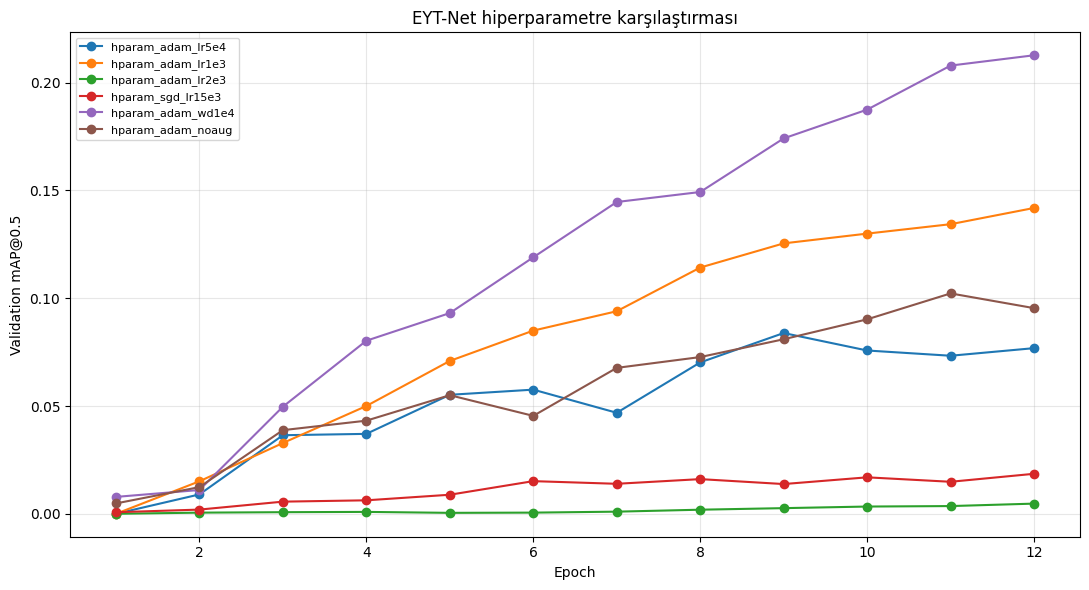

In [53]:
plt.figure(figsize=(11,6))

for run in completed_runs:
    df = pd.read_csv(run["run_dir"] / "metrics.csv")

    df = (
        df.drop_duplicates(subset="epoch", keep="last")
        .sort_values("epoch")
    )

    plt.plot(
        df["epoch"],
        df["map50"],
        marker="o",
        label=run["run_name"],
    )

plt.xlabel("Epoch")
plt.ylabel("Validation mAP@0.5")
plt.title("EYT-Net hiperparametre karşılaştırması")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [17]:
from copy import deepcopy

best_cfg = load_colab_config(
    "experiment_adam_wd1e4"
)

SCREEN_EPOCHS = 12

BASE_SETTINGS = {
    "channels": [32, 64, 128, 256, 512],
    "kernel_size": 3,
    "blocks_per_stage": 2,
    "downsample_mode": "conv",
    "upsample_mode": "nearest",
    "negative_objectness_weight": 0.5,

}

SCENARIOS = {
    "opt_base": {},

    "opt_channels_small": {
        "channels": [24, 48, 96, 192, 384],
    },

    "opt_channels_wide": {
        "channels": [40, 80, 160, 320, 640],
    },

    "opt_kernel5": {
        "kernel_size": 5,
    },

    "opt_blocks3": {
        "blocks_per_stage": 3,
    },

    "opt_maxpool": {
        "downsample_mode": "maxpool",
    },

    "opt_bilinear": {
        "upsample_mode": "bilinear",
    },

    "opt_obj01": {
        "negative_objectness_weight": 0.1,
    },
}

def make_colab_config(raw):
    runtime_raw = deepcopy(raw)

    # config oluştururken gerçek colab datasetini kullan
    runtime_raw["data_root"] = str(DATA_ROOT)

    cfg = Config(runtime_raw)

    # kaydedilen config taşınabilir kalsın.
    cfg.raw["data_root"] = "data"

    cfg.data_root = DATA_ROOT
    cfg.run_dir = (DRIVE_RUNS / cfg.experiment_name)

    return cfg

print("Temel hiperparametre:")
print("Optimizer:", best_cfg.optimizer)
print("Learning rate:", best_cfg.learning_rate)
print("Weight decay:", best_cfg.weight_decay)
print("Senaryo sayısı:", len(SCENARIOS))



Temel hiperparametre:
Optimizer: adam
Learning rate: 0.001
Weight decay: 0.0001
Senaryo sayısı: 8


In [18]:
if "model" in globals():
    del model

torch.cuda.empty_cache()

screen_runs = []

for scenario_name, changes in SCENARIOS.items():
    settings = deepcopy(BASE_SETTINGS)
    settings.update(changes)

    raw = deepcopy(best_cfg.raw)
    raw.update(settings)

    raw["experiment_name"] = (
        f"screen_v1_{scenario_name}"
    )
    raw["epochs"] = SCREEN_EPOCHS
    raw["early_stopping_patience"] = (
        SCREEN_EPOCHS
    )

    cfg_screen = make_colab_config(raw)

    last_checkpoint = (cfg_screen.run_dir / "weights" / "last.pt")

    resume = last_checkpoint.exists()

    print("\n" + "=" * 70)
    print("Senaryo:", scenario_name)
    print("Ayarlar:", settings)
    print("Checkpoint'ten devam:", resume)

    model, run_dir, history = train(
        cfg_screen,
        device=device,
        resume=resume,
    )

    screen_runs.append(
        {
            "name": scenario_name,
            "settings": settings,
            "parameters": model.count_parameters(),
            "run_dir": run_dir,
        }
    )

    del model
    torch.cuda.empty_cache()

print("\nBütün kısa optimizasyon deneyleri tamamlandı.")


Senaryo: opt_base
Ayarlar: {'channels': [32, 64, 128, 256, 512], 'kernel_size': 3, 'blocks_per_stage': 2, 'downsample_mode': 'conv', 'upsample_mode': 'nearest', 'negative_objectness_weight': 0.5}
Checkpoint'ten devam: False
screen_v1_opt_base | 7,208,138 parametre | cuda
  [50/121] loss=6.2073 lr=0.00040
  [100/121] loss=5.8503 lr=0.00082
epoch 1/12 | loss 5.7050 | mAP@0.5 0.0078 | F2 0.0000 | 76.2s
  [50/121] loss=4.8976 lr=0.00100
  [100/121] loss=4.8302 lr=0.00099
epoch 2/12 | loss 4.7794 | mAP@0.5 0.0110 | F2 0.0000 | 73.0s
  [50/121] loss=4.5124 lr=0.00096
  [100/121] loss=4.4491 lr=0.00094
epoch 3/12 | loss 4.4242 | mAP@0.5 0.0497 | F2 0.0126 | 89.6s
  [50/121] loss=4.2149 lr=0.00089
  [100/121] loss=4.1324 lr=0.00085
epoch 4/12 | loss 4.1111 | mAP@0.5 0.0803 | F2 0.0619 | 79.9s
  [50/121] loss=3.9934 lr=0.00079
  [100/121] loss=3.9510 lr=0.00074
epoch 5/12 | loss 3.9201 | mAP@0.5 0.0931 | F2 0.0422 | 77.8s
  [50/121] loss=3.7425 lr=0.00067
  [100/121] loss=3.7427 lr=0.00062
epo

In [19]:
screen_rows = []

for run in screen_runs:
    df = pd.read_csv( run["run_dir"] / "metrics.csv")

    df = (df.drop_duplicates(subset="epoch", keep = "last",).sort_values("epoch"))

    best = df.loc[df["map50"].idxmax()]
    screen_rows.append(
        {
            "senaryo": run["name"],
            "parametre": run["parameters"],
            "best_epoch": int(best["epoch"]),
            "mAP@0.5": float(best["map50"]),
            "precision": float(best["precision"]),
            "recall": float(best["recall"]),
            "F1": float(best["f1"]),
            "F2": float(best["f2"]),
            "epoch_saniye": float(
                df["seconds"].mean()
            ),
        }
    )

screen_comparison = (
    pd.DataFrame(screen_rows)
    .sort_values(
        ["mAP@0.5", "parametre"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(screen_comparison.round(4))
winner_name = screen_comparison.iloc[0]["senaryo"]

base_map = float(screen_comparison.loc[screen_comparison["senaryo"] == "opt_base", "mAP@0.5",].iloc[0])

winner_map = float(screen_comparison.iloc[0]["mAP@0.5"])

# Çok küçük fark varsa daha güvenli olan temel mimariyi seç.
if winner_map - base_map < 0.01:
    selected_name = "opt_base"
    print(
        "Fark 0.01'den küçük; temel mimari seçildi."
    )
else:
    selected_name = winner_name

selected_run = next(
    run for run in screen_runs
    if run["name"] == selected_name
)

print("\nFinal için seçilen:", selected_name)
print("Ayarlar:", selected_run["settings"])



,senaryo,parametre,best_epoch,mAP@0.5,precision,recall,F1,F2,epoch_saniye
0,opt_obj01,7208138,12,0.2549,0.2366,0.4297,0.3052,0.3694,152.2583
1,opt_maxpool,7208138,12,0.2464,0.6947,0.1570,0.2561,0.1857,75.4250
2,opt_kernel5,19759818,12,0.2137,0.7038,0.1639,0.2659,0.1936,75.8250
3,opt_base,7208138,12,0.2127,0.6814,0.1462,0.2408,0.1734,77.1000
4,opt_channels_wide,11257202,12,0.2109,0.6513,0.1703,0.2699,0.1998,80.2167
5,opt_blocks3,10343498,12,0.2050,0.6562,0.1582,0.2550,0.1865,74.6917
6,opt_bilinear,7208138,12,0.2011,0.6500,0.1399,0.2302,0.1659,73.9333
7,opt_channels_small,4057890,12,0.1698,0.5968,0.1171,0.1958,0.1395,71.3667



Final için seçilen: opt_obj01
Ayarlar: {'channels': [32, 64, 128, 256, 512], 'kernel_size': 3, 'blocks_per_stage': 2, 'downsample_mode': 'conv', 'upsample_mode': 'nearest', 'negative_objectness_weight': 0.1}


In [20]:
FINAL_EPOCHS = 60

final_raw = deepcopy(best_cfg.raw)
final_raw.update(selected_run["settings"])

final_raw["experiment_name"] = (f"eytnet_final_v1_{selected_name}")

final_raw["epochs"] = FINAL_EPOCHS
final_raw["early_stopping_patience"] = 10

cfg_final = make_colab_config(final_raw)

last_checkpoint_final = (cfg_final.run_dir / "weights" / "last.pt")

resume_final = last_checkpoint_final.exists()

print("final deney:", cfg_final.experiment_name)
print("Mimari:", selected_run["settings"])
print("Epoch:", cfg_final.epochs)
print("Çıktı:", cfg_final.run_dir)
print("Checkpoint'ten devam:", resume_final)

model_final, run_dir_final, history_final = train(
    cfg_final,
    device=device,
    resume=resume_final,
)

print("\nFinal eğitim tamamlandı.")
print(
    "Best checkpoint:",
    run_dir_final / "weights" / "best.pt",
)

final deney: eytnet_final_v1_opt_obj01
Mimari: {'channels': [32, 64, 128, 256, 512], 'kernel_size': 3, 'blocks_per_stage': 2, 'downsample_mode': 'conv', 'upsample_mode': 'nearest', 'negative_objectness_weight': 0.1}
Epoch: 60
Çıktı: /content/drive/MyDrive/EYTNet/runs/eytnet_final_v1_opt_obj01
Checkpoint'ten devam: False
eytnet_final_v1_opt_obj01 | 7,208,138 parametre | cuda
  [50/121] loss=6.2246 lr=0.00040
  [100/121] loss=5.8528 lr=0.00082
epoch 1/60 | loss 5.7045 | mAP@0.5 0.0072 | F2 0.0198 | 135.0s
  [50/121] loss=4.9427 lr=0.00100
  [100/121] loss=4.8918 lr=0.00100
epoch 2/60 | loss 4.8464 | mAP@0.5 0.0587 | F2 0.0335 | 186.5s
  [50/121] loss=4.5756 lr=0.00100
  [100/121] loss=4.5053 lr=0.00100
epoch 3/60 | loss 4.4916 | mAP@0.5 0.0788 | F2 0.1963 | 218.9s
  [50/121] loss=4.3058 lr=0.00100
  [100/121] loss=4.2231 lr=0.00099
epoch 4/60 | loss 4.2116 | mAP@0.5 0.0877 | F2 0.2409 | 193.7s
  [50/121] loss=4.0192 lr=0.00099
  [100/121] loss=4.0207 lr=0.00099
epoch 5/60 | loss 4.0116 |

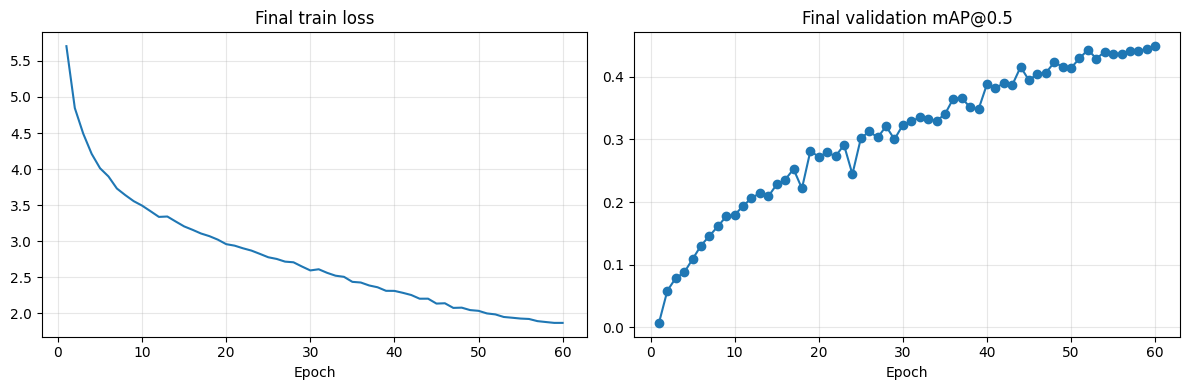

En iyi epoch: 60
En iyi mAP@0.5: 0.4489
Precision (eşik 0.25): 0.2798
Recall (eşik 0.25): 0.662
F2 (eşik 0.25): 0.52
Best checkpoint: /content/drive/MyDrive/EYTNet/runs/eytnet_final_v1_opt_obj01/weights/best.pt


In [21]:
df_final = pd.read_csv(run_dir_final / "metrics.csv")

df_final = (df_final.drop_duplicates(subset="epoch", keep = "last",).sort_values("epoch"))

best_final = df_final.loc[df_final["map50"].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    df_final["epoch"],
    df_final["train_loss"],
)
axes[0].set_title("Final train loss")

axes[1].plot(
    df_final["epoch"],
    df_final["map50"],
    marker="o",
)
axes[1].set_title("Final validation mAP@0.5")

for axis in axes:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("En iyi epoch:", int(best_final["epoch"]))
print(
    "En iyi mAP@0.5:",
    round(float(best_final["map50"]), 4),
)
print(
    "Precision (eşik 0.25):",
    round(float(best_final["precision"]), 4),
)
print(
    "Recall (eşik 0.25):",
    round(float(best_final["recall"]), 4),
)
print(
    "F2 (eşik 0.25):",
    round(float(best_final["f2"]), 4),
)
print(
    "Best checkpoint:",
    run_dir_final / "weights" / "best.pt",
)

In [22]:
from copy import deepcopy

SCHEDULER_SCENARIOS = {
    "hparam_adam_wd1e4_static": {
        "lr_scheduler": "constant",
        "warmup_epochs": 0,
    },
    "hparam_adam_wd1e4_static_warmup1": {
        "lr_scheduler": "constant",
        "warmup_epochs": 1,
    },
    "hparam_adam_wd1e4_cosine_nowarmup": {
        "lr_scheduler": "cosine",
        "warmup_epochs": 0,
    },
}

scheduler_training_runs = []

for experiment_name, changes in (
    SCHEDULER_SCENARIOS.items()
):
    raw = deepcopy(best_cfg.raw)

    # Bütün deneylerde aynı temel mimari
    raw.update(
        {
            "channels": [32, 64, 128, 256, 512],
            "kernel_size": 3,
            "blocks_per_stage": 2,
            "downsample_mode": "conv",
            "upsample_mode": "nearest",
            "negative_objectness_weight": 0.5,
        }
    )

    raw.update(changes)

    raw["experiment_name"] = experiment_name
    raw["epochs"] = 12
    raw["early_stopping_patience"] = 12

    cfg_scheduler = make_colab_config(raw)

    last_checkpoint = (
        cfg_scheduler.run_dir
        / "weights"
        / "last.pt"
    )

    resume = last_checkpoint.exists()

    print("\n" + "=" * 70)
    print("Deney:", experiment_name)
    print(
        "Scheduler:",
        cfg_scheduler.lr_scheduler,
    )
    print(
        "Warmup:",
        cfg_scheduler.warmup_epochs,
    )
    print("Checkpoint'ten devam:", resume)

    model_scheduler, run_dir, history = train(
        cfg_scheduler,
        device=device,
        resume=resume,
    )

    scheduler_training_runs.append(
        {
            "name": experiment_name,
            "run_dir": run_dir,
        }
    )

    del model_scheduler
    torch.cuda.empty_cache()

print("Scheduler deneyleri tamamlandı.")


Deney: hparam_adam_wd1e4_static
Scheduler: constant
Warmup: 0
Checkpoint'ten devam: False
hparam_adam_wd1e4_static | 7,208,138 parametre | cuda
  [50/121] loss=5.9829 lr=0.00100
  [100/121] loss=5.6502 lr=0.00100
epoch 1/12 | loss 5.5280 | mAP@0.5 0.0007 | F2 0.0000 | 70.2s
  [50/121] loss=4.8373 lr=0.00100
  [100/121] loss=4.7937 lr=0.00100
epoch 2/12 | loss 4.7446 | mAP@0.5 0.0059 | F2 0.0000 | 75.6s
  [50/121] loss=4.5327 lr=0.00100
  [100/121] loss=4.4823 lr=0.00100
epoch 3/12 | loss 4.4672 | mAP@0.5 0.0484 | F2 0.0352 | 84.5s
  [50/121] loss=4.2636 lr=0.00100
  [100/121] loss=4.2361 lr=0.00100
epoch 4/12 | loss 4.2241 | mAP@0.5 0.0611 | F2 0.0841 | 82.6s
  [50/121] loss=4.0920 lr=0.00100
  [100/121] loss=4.0650 lr=0.00100
epoch 5/12 | loss 4.0445 | mAP@0.5 0.0703 | F2 0.0126 | 76.7s
  [50/121] loss=3.8745 lr=0.00100
  [100/121] loss=3.9093 lr=0.00100
epoch 6/12 | loss 3.9073 | mAP@0.5 0.0962 | F2 0.0521 | 72.7s
  [50/121] loss=3.8574 lr=0.00100
  [100/121] loss=3.8579 lr=0.00100


,scheduler,best_epoch,mAP@0.5,precision,recall,F1,F2
0,Cosine + warmup,12,0.2127,0.6814,0.1462,0.2408,0.1734
1,"Cosine, warmup yok",12,0.1805,0.5914,0.1475,0.2361,0.1735
2,"Static, warmup yok",12,0.1633,0.4720,0.1816,0.2623,0.2071
3,Static + warmup,12,0.1618,0.4913,0.1437,0.2223,0.1674


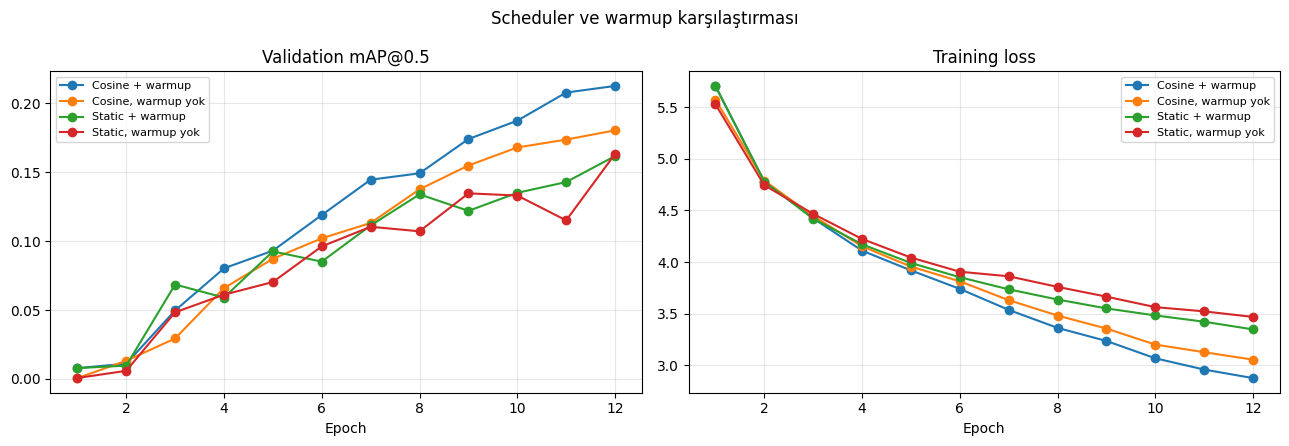

En iyi ayar: Cosine + warmup


In [18]:
scheduler_runs = [
    {
        "name": "Cosine + warmup",
        "run_dir": (
            DRIVE_RUNS
            / "hparam_adam_wd1e4"
        ),
    },
    {
        "name": "Cosine, warmup yok",
        "run_dir": (
            DRIVE_RUNS
            / "hparam_adam_wd1e4_cosine_nowarmup"
        ),
    },
    {
        "name": "Static + warmup",
        "run_dir": (
            DRIVE_RUNS
            / "hparam_adam_wd1e4_static_warmup1"
        ),
    },
    {
        "name": "Static, warmup yok",
        "run_dir": (
            DRIVE_RUNS
            / "hparam_adam_wd1e4_static"
        ),
    },
]

scheduler_rows = []

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
)

for run in scheduler_runs:
    metrics_path = (
        run["run_dir"] / "metrics.csv"
    )

    assert metrics_path.is_file(), (
        f"Sonuç bulunamadı: {metrics_path}"
    )

    df = pd.read_csv(metrics_path)

    df = (
        df.drop_duplicates(
            subset="epoch",
            keep="last",
        )
        .sort_values("epoch")
    )

    df = df[df["epoch"] <= 12]
    best = df.loc[df["map50"].idxmax()]

    scheduler_rows.append(
        {
            "scheduler": run["name"],
            "best_epoch": int(best["epoch"]),
            "mAP@0.5": float(best["map50"]),
            "precision": float(best["precision"]),
            "recall": float(best["recall"]),
            "F1": float(best["f1"]),
            "F2": float(best["f2"]),
        }
    )

    axes[0].plot(
        df["epoch"],
        df["map50"],
        marker="o",
        label=run["name"],
    )

    axes[1].plot(
        df["epoch"],
        df["train_loss"],
        marker="o",
        label=run["name"],
    )

scheduler_comparison = (
    pd.DataFrame(scheduler_rows)
    .sort_values(
        ["mAP@0.5", "F2"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(scheduler_comparison.round(4))

axes[0].set_title("Validation mAP@0.5")
axes[1].set_title("Training loss")

for axis in axes:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.3)
    axis.legend(fontsize=8)

plt.suptitle(
    "Scheduler ve warmup karşılaştırması"
)
plt.tight_layout()
plt.show()

print(
    "En iyi ayar:",
    scheduler_comparison.iloc[0]["scheduler"],
)